In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

batting = pd.read_csv('data/Batting.csv')

print(batting.head())



    playerID  yearID  stint teamID lgID   G  AB  R  H  2B  ...  RBI   SB   CS  \
0  aardsda01    2004      1    SFN   NL  11   0  0  0   0  ...  0.0  0.0  0.0   
1  aardsda01    2006      1    CHN   NL  45   2  0  0   0  ...  0.0  0.0  0.0   
2  aardsda01    2007      1    CHA   AL  25   0  0  0   0  ...  0.0  0.0  0.0   
3  aardsda01    2008      1    BOS   AL  47   1  0  0   0  ...  0.0  0.0  0.0   
4  aardsda01    2009      1    SEA   AL  73   0  0  0   0  ...  0.0  0.0  0.0   

   BB   SO  IBB  HBP   SH   SF  GIDP  
0   0  0.0  0.0  0.0  0.0  0.0   0.0  
1   0  0.0  0.0  0.0  1.0  0.0   0.0  
2   0  0.0  0.0  0.0  0.0  0.0   0.0  
3   0  1.0  0.0  0.0  0.0  0.0   0.0  
4   0  0.0  0.0  0.0  0.0  0.0   0.0  

[5 rows x 22 columns]


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

batting = pd.read_csv('data/Batting.csv')

top_hitters = (
    batting.groupby("playerID")["H"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_hitters

# this shows the top 10 hitters by total hits in their careers.

playerID
rosepe01     4256
cobbty01     4189
aaronha01    3771
musiast01    3630
speaktr01    3514
jeterde01    3465
ansonca01    3435
wagneho01    3420
yastrca01    3419
pujolal01    3384
Name: H, dtype: int64

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

batting = pd.read_csv('data/Batting.csv')

active_players = batting[batting['AB'] > 0]
active_players.describe()
batting.groupby('playerID')['HR'].sum().sort_values(ascending=False)

# this shows the top 10 players by total home runs in their careers.

playerID
bondsba01    762
aaronha01    755
ruthba01     714
pujolal01    703
rodrial01    696
            ... 
abadijo01      0
abadfe01       0
zmiched01      0
abbotky01      0
zettlge01      0
Name: HR, Length: 24011, dtype: int64

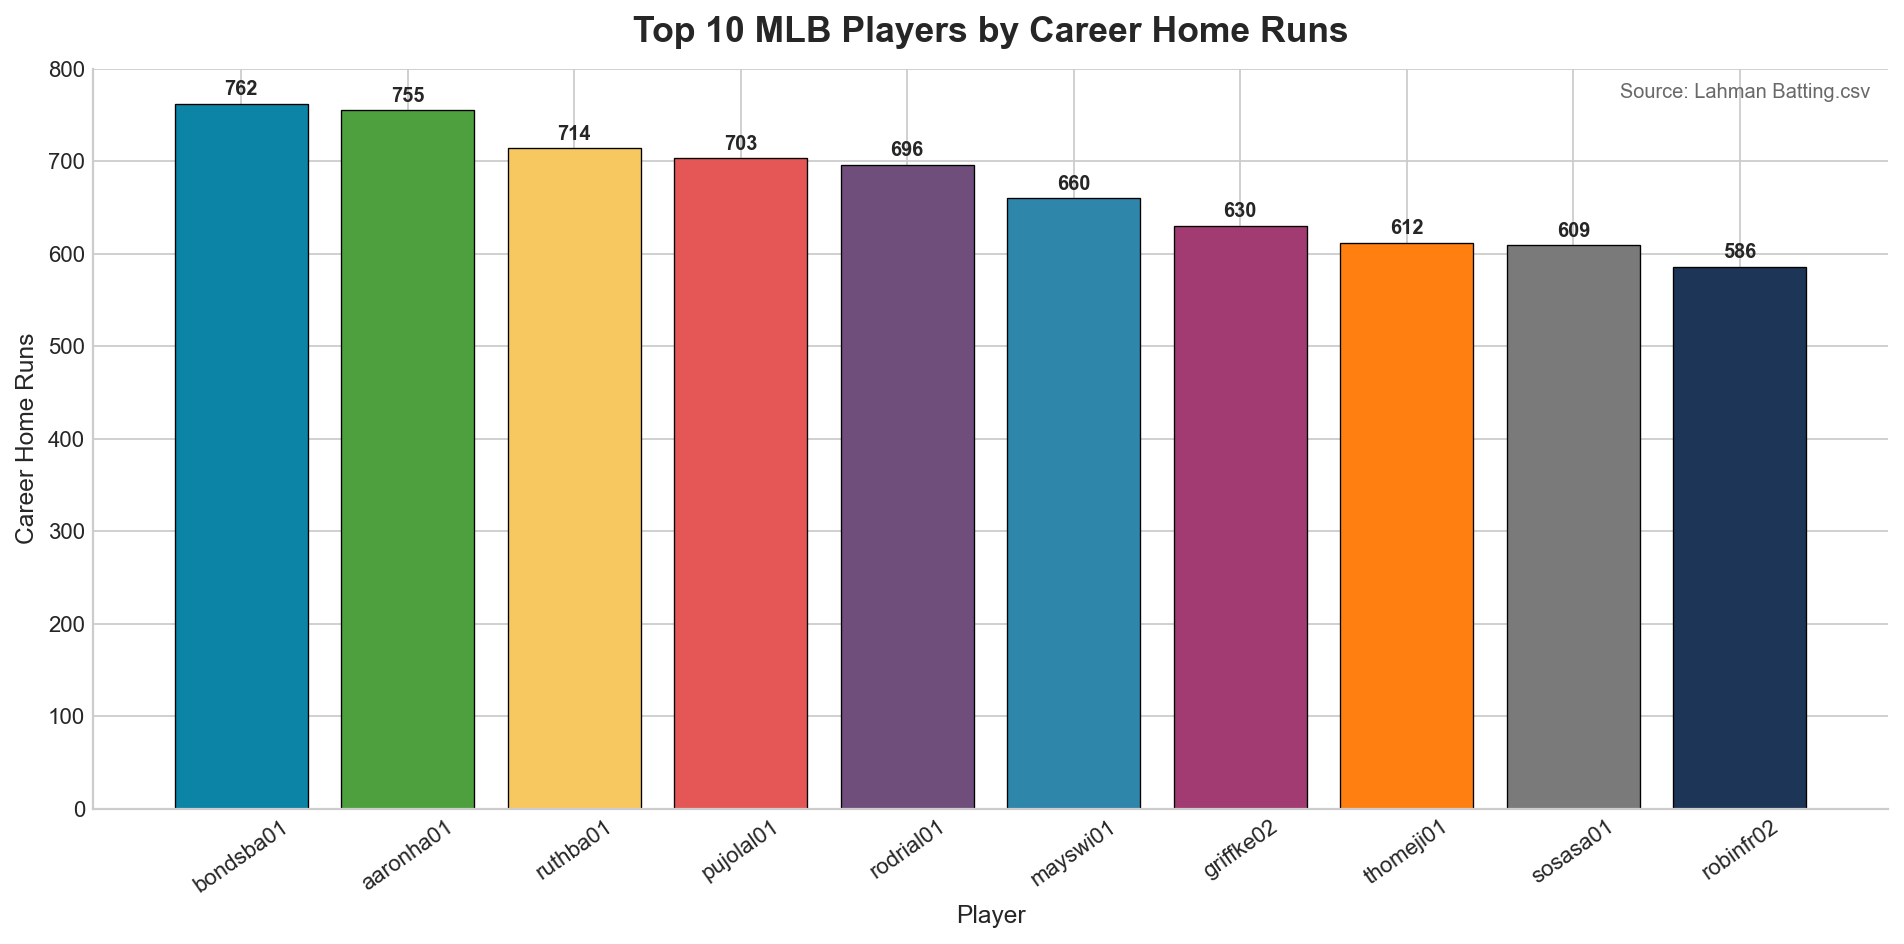

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

batting = pd.read_csv('data/Batting.csv')
top_hr = batting.groupby('playerID')['HR'].sum().sort_values(ascending=False).head(10)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6), dpi=160)

colors = ['#0B84A5','#4E9F3D','#F6C85F','#E45756','#6F4E7C',
          '#2E86AB','#A23B72','#FF7F11','#7A7A7A','#1D3557']

bars = ax.bar(top_hr.index, top_hr.values, color=colors, edgecolor='black', linewidth=0.6)

ax.set_title('Top 10 MLB Players by Career Home Runs', fontsize=16, weight='bold', pad=12)
ax.set_xlabel('Player', fontsize=11)
ax.set_ylabel('Career Home Runs', fontsize=11)
ax.tick_params(axis='x', rotation=35)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 5, f'{int(h)}',
            ha='center', va='bottom', fontsize=9, weight='bold')

ax.text(0.99, 0.98, 'Source: Lahman Batting.csv',
        transform=ax.transAxes, ha='right', va='top', fontsize=9, color='dimgray')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('top_10_hr_linkedin.png', bbox_inches='tight')
plt.show()
